In [135]:
import pandas as pd 
import numpy as np 
import re
import matplotlib.pyplot as plt 
import seaborn as sns 

In [136]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [137]:
df = df.drop(columns=["customerID"])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce') 
df.dropna(subset=["TotalCharges"],inplace=True)

In [138]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


# EDA



In [139]:
numeric=['tenure','MonthlyCharges','TotalCharges']
categorical=['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

## EDA of numeric ones 

--------Analysis for tenure---------
count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64
Skewness=0.24


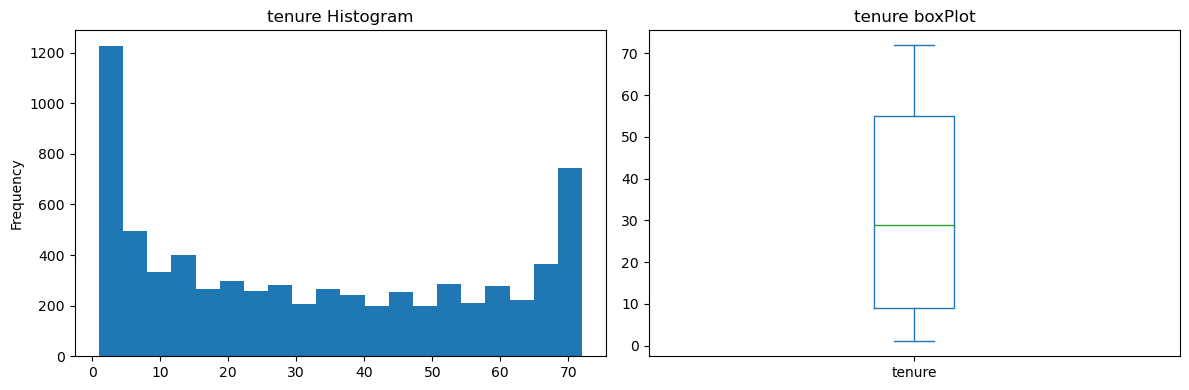

--------Analysis for MonthlyCharges---------
count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64
Skewness=-0.22


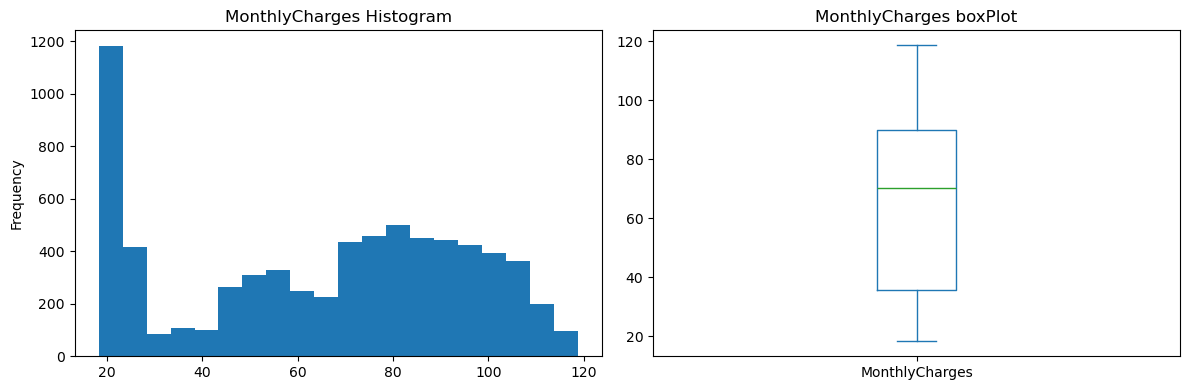

--------Analysis for TotalCharges---------
count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64
Skewness=0.96


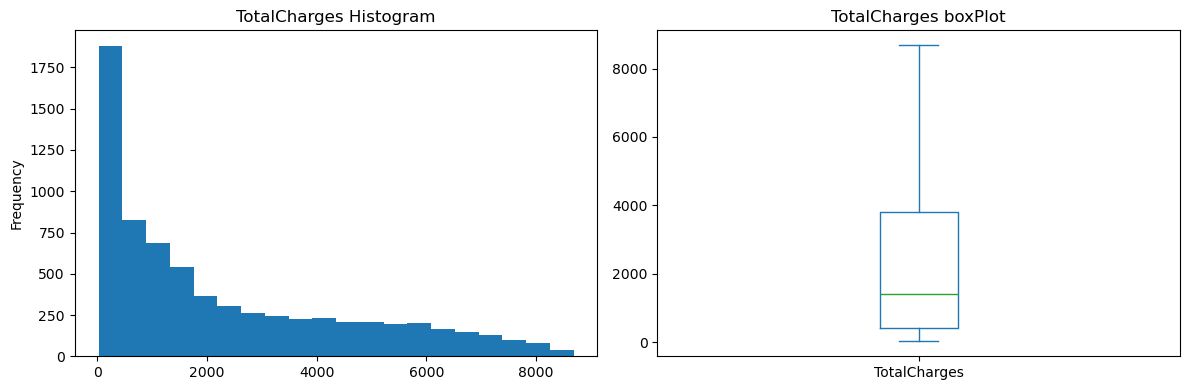

In [143]:
for col in numeric:
    print(f"--------Analysis for {col}---------")

    print(df[col].describe())
    print(f"Skewness={df[col].skew():.2f}")

    fig, axis = plt.subplots(1,2,figsize=(12,4))
    df[col].plot(kind="hist",bins=20,ax=axis[0],title=f"{col} Histogram")
    df[col].plot(kind="box",ax=axis[1],title=f"{col} boxPlot")

    plt.tight_layout()
    plt.show()

In [144]:
print(df['Churn'].value_counts(normalize=True)*100)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


# Feature Engineering 

In [95]:
df["StreamingMovies"].value_counts()

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

In [89]:
# Encode yes and no values to 0 and 1 and if three values then 0,1,2 accordingly

Encodable_feilds_two_values=['Partner', 'Dependents', 'PhoneService',  'PaperlessBilling', 'Churn']
Encodable_feilds_three_values= ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
def encoding_values(df):
    for feature in df.columns:
        if feature in Encodable_feilds_two_values:
           df[feature] = df[feature].apply(lambda x:1 if x == "Yes" else 0)
        if feature in Encodable_feilds_three_values:
           df[feature] = df[feature].apply(lambda x:0 if x == "No phone service" or x == "No internet service" else(1 if x=="No" else 2))
    return df
df = encoding_values(df)         

In [90]:
 df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,0,DSL,1,2,1,1,1,1,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,1,DSL,2,1,2,1,1,1,One year,0,Mailed check,56.95,1889.5,0
2,Male,0,0,0,2,1,1,DSL,2,2,1,1,1,1,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,0,DSL,2,1,2,2,1,1,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,1,Fiber optic,1,1,1,1,1,1,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,1,1,24,1,2,DSL,2,1,2,2,2,2,One year,1,Mailed check,84.80,1990.5,0
7039,Female,0,1,1,72,1,2,Fiber optic,1,2,2,1,2,2,One year,1,Credit card (automatic),103.20,7362.9,0
7040,Female,0,1,1,11,0,0,DSL,2,1,1,1,1,1,Month-to-month,1,Electronic check,29.60,346.45,0
7041,Male,1,1,0,4,1,2,Fiber optic,1,1,1,1,1,1,Month-to-month,1,Mailed check,74.40,306.6,1
